# Iris Dataset Task 1, 2 and 3
### Data Cleaning · Exploratory Data Analysis · Data Visualization
**Dataset:** `iris.csv`
**Tools:** Python, pandas, matplotlib, seaborn


---
# Task 1 : Data Cleaning and Preprocessing




In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

INPUT_FILE = "1) iris.csv"
OUTPUT_FILE = "iris_cleaned.csv"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

## Load the Dataset


In [27]:
df = pd.read_csv(INPUT_FILE)

print(f"Rows loaded    : {df.shape[0]}")
print(f"Columns loaded : {df.shape[1]}")
print(f"Column names   : {list(df.columns)}")
df.head()

Rows loaded    : 150
Columns loaded : 5
Column names   : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


##  Identify and Handle Missing Values



In [29]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_counts, "missing_%": missing_pct})
missing_report

,missing_count,missing_%
sepal_length,0,0.0
sepal_width,0,0.0
petal_length,0,0.0
petal_width,0,0.0
species,0,0.0


In [30]:
total_missing = missing_counts.sum()

if total_missing == 0:
    print("No missing values found in any column. No imputation or removal needed.")
else:
    for col in df.columns:
        pct = missing_pct[col]
        if pct == 0:
            continue
        if pct > 40:
            print(f"Dropping column '{col}' ({pct}% missing).")
            df = df.drop(columns=[col])
        elif df[col].dtype.kind in "biufc":
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"Imputed numeric column '{col}' with median = {median_val}")
        else:
            mode_val = df[col].mode(dropna=True)[0]
            df[col] = df[col].fillna(mode_val)
            print(f"Imputed categorical column '{col}' with mode = '{mode_val}'")

No missing values found in any column. No imputation or removal needed.


## Remove Duplicate Rows



In [31]:
n_before = len(df)
duplicate_mask = df.duplicated(keep=False)
print(f"Rows involved in duplicate sets: {duplicate_mask.sum()}")
df[duplicate_mask].sort_values(by=list(df.columns))

Rows involved in duplicate sets: 5


,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [32]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)
n_after = len(df)

print(f"Rows before : {n_before}")
print(f"Rows after  : {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before : 150
Rows after  : 147
Rows removed: 3


## Standardize Inconsistent Formats



In [33]:
old_columns = list(df.columns)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print(f"Column names: {old_columns} -> {list(df.columns)}")

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'] -> ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [34]:
df["species"] = df["species"].astype(str).str.strip().str.lower()
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [35]:
measurement_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
for col in measurement_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [36]:
invalid = (df[measurement_cols] <= 0).sum().sum()
print(f"Invalid (<= 0) measurement values found: {invalid}")

Invalid (<= 0) measurement values found: 0


In [37]:
print(f"Final shape             : {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")
print()
print("Class balance ('species'):")
print(df["species"].value_counts())

Final shape             : (147, 5)
Remaining missing values: 0
Remaining duplicate rows: 0

Class balance ('species'):
species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64


In [38]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [39]:
df.to_csv(OUTPUT_FILE, index=False)
print(f"Cleaned dataset exported to: {OUTPUT_FILE}")

Cleaned dataset exported to: iris_cleaned.csv


---
# Task 2 :Exploratory Data Analysis (EDA)




In [40]:
summary_stats = pd.DataFrame({
    "mean": df[measurement_cols].mean(),
    "median": df[measurement_cols].median(),
    "mode": df[measurement_cols].mode().iloc[0],
    "std": df[measurement_cols].std(),
    "min": df[measurement_cols].min(),
    "max": df[measurement_cols].max(),
})
summary_stats

,mean,median,mode,std,min,max
sepal_length,5.856463,5.8,5.0,0.829100,4.3,7.9
sepal_width,3.055782,3.0,3.0,0.437009,2.0,4.4
petal_length,3.780272,4.4,1.4,1.759111,1.0,6.9
petal_width,1.208844,1.3,0.2,0.757874,0.1,2.5


In [41]:
stats_by_species = df.groupby("species")[measurement_cols].agg(["mean", "median", "std"]).round(2)
stats_by_species

sepal_length              sepal_width              petal_length              petal_width             
                   mean median   std        mean median   std         mean median   std        mean median   std
species                                                                                                         
setosa             5.01    5.0  0.36        3.43    3.4  0.38         1.46   1.50  0.18        0.25    0.2  0.11
versicolor         5.94    5.9  0.52        2.77    2.8  0.31         4.26   4.35  0.47        1.33    1.3  0.20
virginica          6.60    6.5  0.63        2.98    3.0  0.32         5.56   5.60  0.55        2.03    2.0  0.28

##  Distribution: Histograms

One histogram per numeric feature, with a KDE curve overlaid to visualize the shape of the distribution.

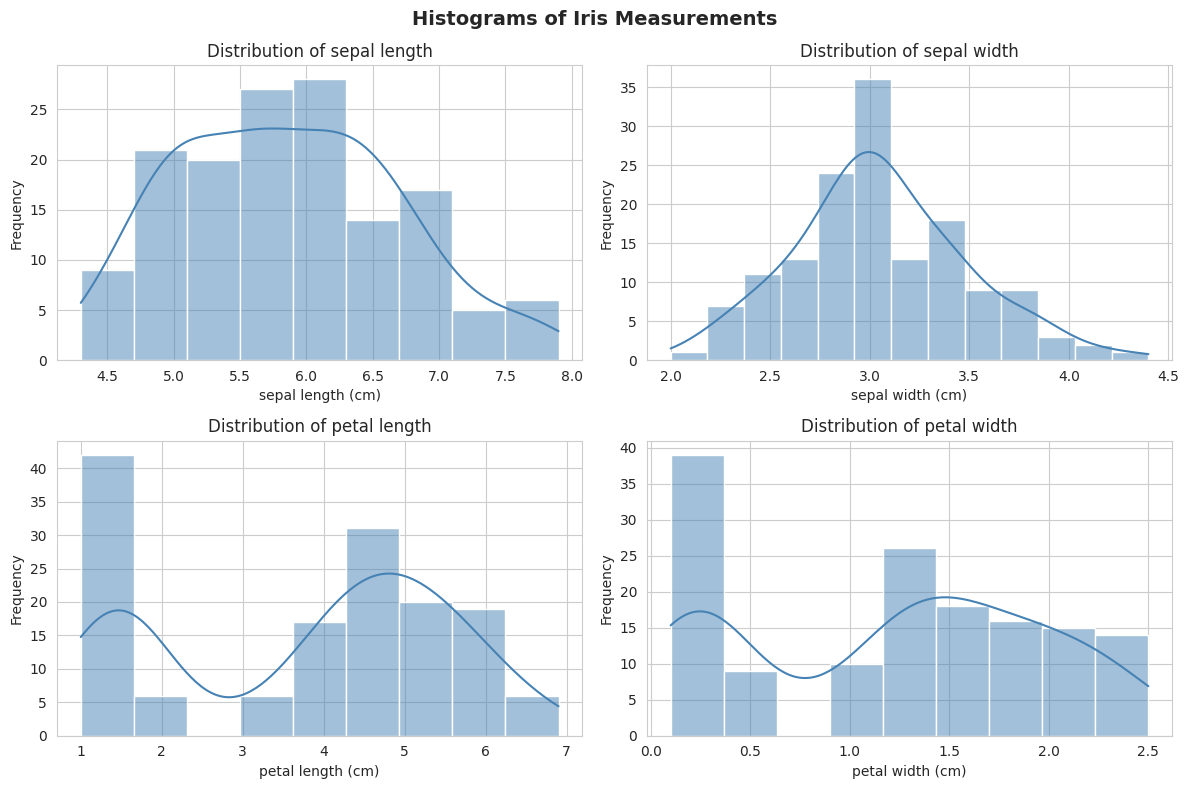

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), measurement_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col.replace('_', ' ')}")
    ax.set_xlabel(f"{col.replace('_', ' ')} (cm)")
    ax.set_ylabel("Frequency")
plt.suptitle("Histograms of Iris Measurements", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_histograms.png", dpi=150)
plt.show()

## Distribution by Class: Boxplots

Boxplots per species highlight the spread, median, and outliers of each measurement, and how clearly they separate the three species.

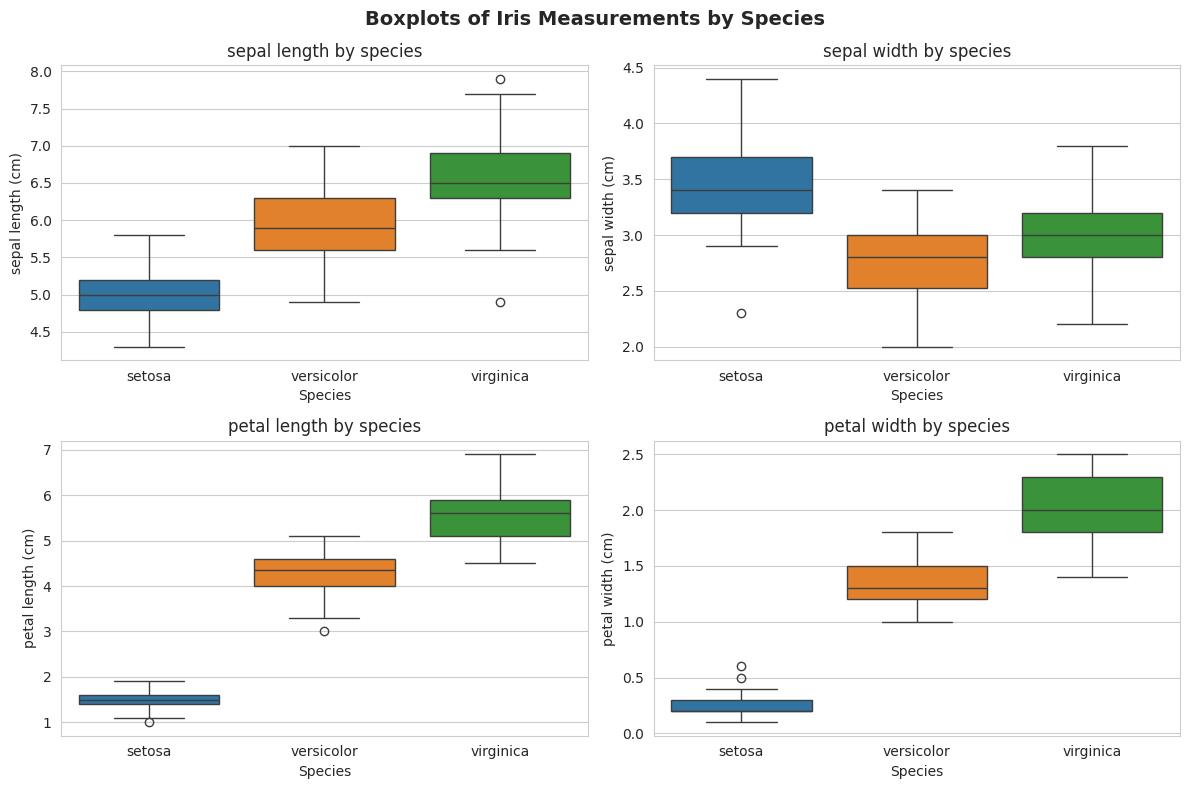

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), measurement_cols):
    sns.boxplot(data=df, x="species", y=col, hue="species", ax=ax, legend=False)
    ax.set_title(f"{col.replace('_', ' ')} by species")
    ax.set_xlabel("Species")
    ax.set_ylabel(f"{col.replace('_', ' ')} (cm)")
plt.suptitle("Boxplots of Iris Measurements by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_boxplots.png", dpi=150)
plt.show()

## Relationships: Scatter Plots (Pairplot)

A pairplot shows every pairwise relationship between the four numeric features at once, colored by species, to spot patterns and separability visually.

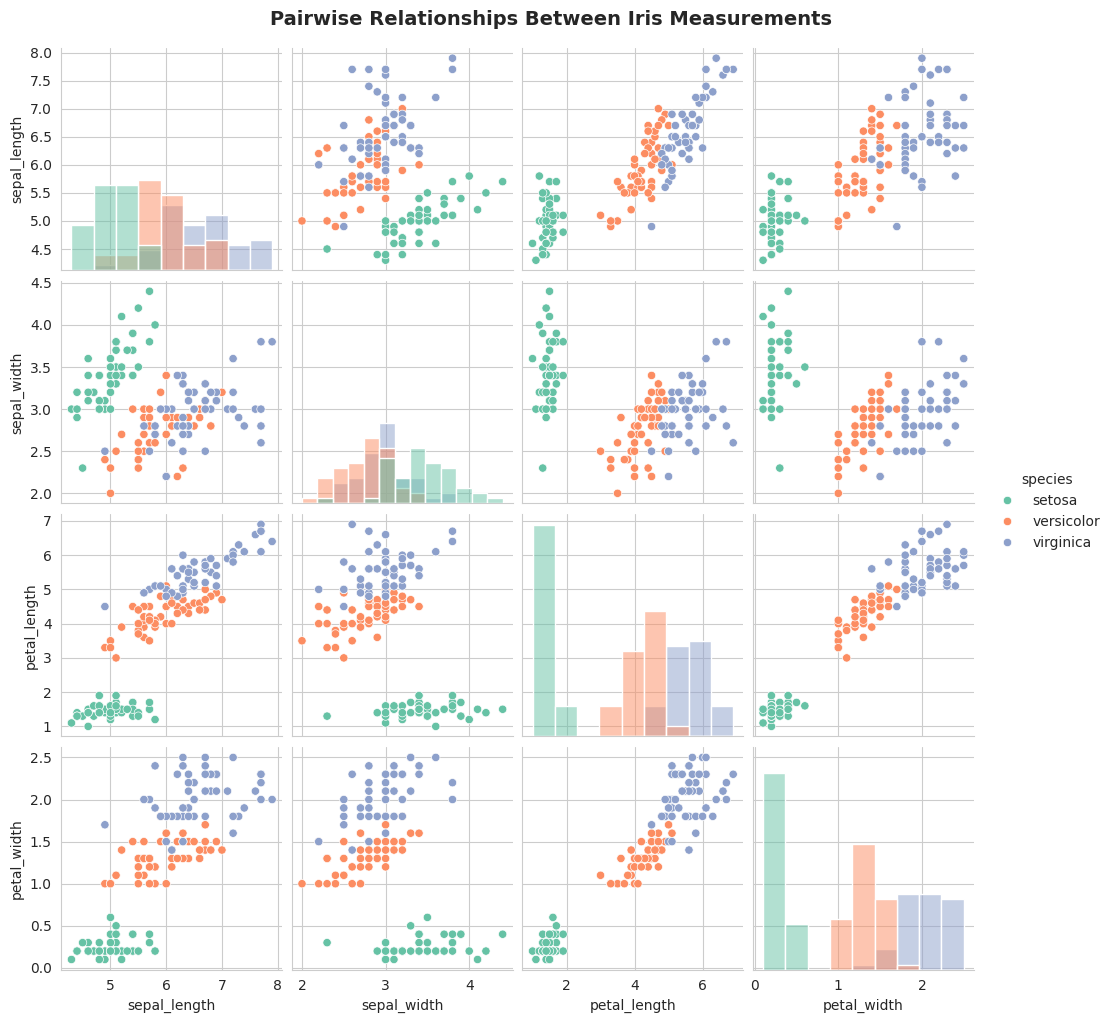

In [44]:
pair = sns.pairplot(df, hue="species", vars=measurement_cols, palette="Set2", diag_kind="hist")
pair.fig.suptitle("Pairwise Relationships Between Iris Measurements", y=1.02, fontsize=14, fontweight="bold")
pair.savefig(f"{PLOTS_DIR}/eda_pairplot.png", dpi=150)
plt.show()

## Correlation Between Numerical Features

In [45]:
corr_matrix = df[measurement_cols].corr()
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


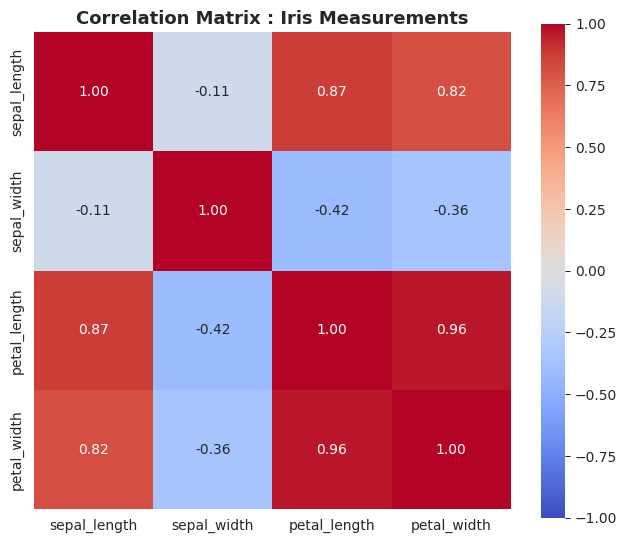

In [46]:
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix : Iris Measurements", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_correlation_heatmap.png", dpi=150)
plt.show()

**Reading the correlation matrix:** petal length and petal width are almost perfectly correlated (r ≈ 0.96), and both are strongly correlated with sepal length. Sepal width is the only feature that correlates *negatively*, and weakly, with the others it behaves quite differently, which is consistent with it being the least useful single feature for separating species.

---
# Task 3 : Basic Data Visualization



## Bar Plot: Sample Count per Species

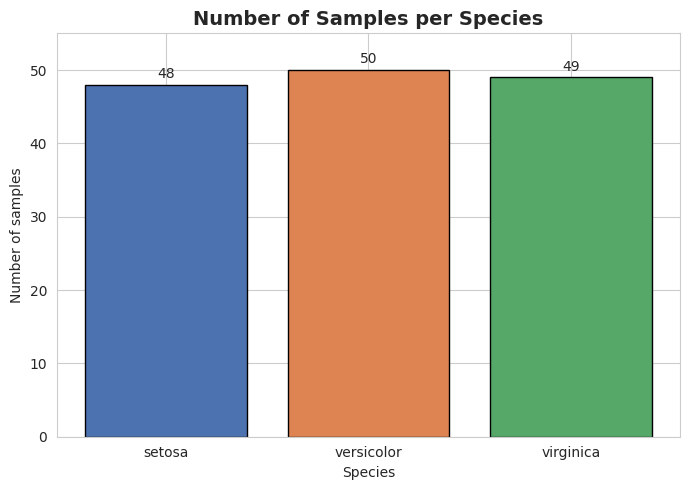

In [47]:
species_counts = df["species"].value_counts().sort_index()
colors = ["#4C72B0", "#DD8452", "#55A868"]

plt.figure(figsize=(7, 5))
bars = plt.bar(species_counts.index, species_counts.values, color=colors, edgecolor="black")
plt.title("Number of Samples per Species", fontsize=14, fontweight="bold")
plt.xlabel("Species")
plt.ylabel("Number of samples")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, str(int(height)),
              ha="center", va="bottom", fontsize=10)
plt.ylim(0, species_counts.max() + 5)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/viz_barplot_species_count.png", dpi=150)
plt.show()

## Line Chart: Average Measurements per Species

Iris has no time dimension, so the line chart here tracks how the **average value of each measurement changes across species** — a clean way to show a trend across an ordered category using a line chart.

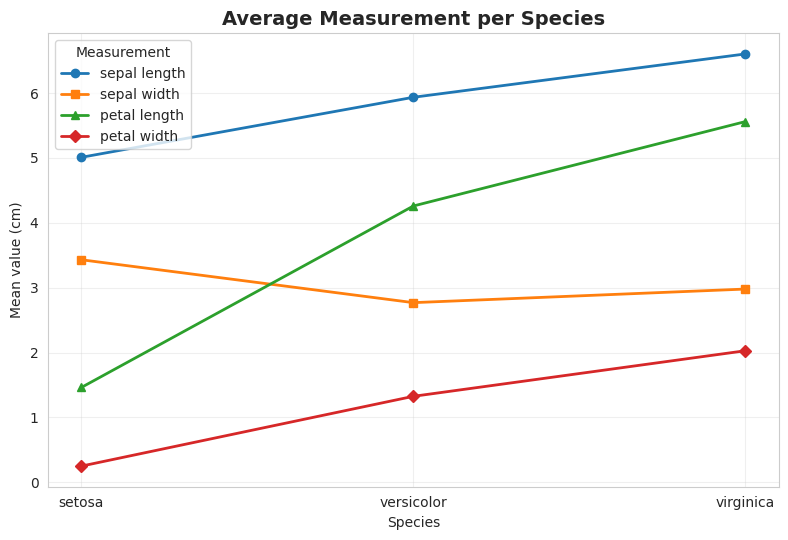

In [48]:
means_by_species = df.groupby("species")[measurement_cols].mean()

plt.figure(figsize=(8, 5.5))
markers = ["o", "s", "^", "D"]
for col, marker in zip(measurement_cols, markers):
    plt.plot(means_by_species.index, means_by_species[col], marker=marker,
              linewidth=2, label=col.replace("_", " "))
plt.title("Average Measurement per Species", fontsize=14, fontweight="bold")
plt.xlabel("Species")
plt.ylabel("Mean value (cm)")
plt.legend(title="Measurement", loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/viz_linechart_mean_by_species.png", dpi=150)
plt.show()

##  Scatter Plot: Sepal Length vs Sepal Width

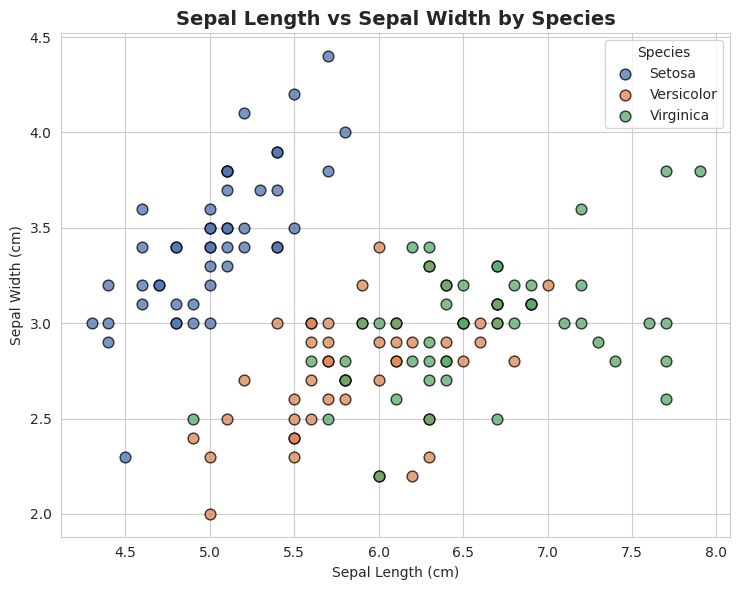

In [49]:
species_colors = {"setosa": "#4C72B0", "versicolor": "#DD8452", "virginica": "#55A868"}

plt.figure(figsize=(7.5, 6))
for sp, color in species_colors.items():
    subset = df[df["species"] == sp]
    plt.scatter(subset["sepal_length"], subset["sepal_width"],
                label=sp.capitalize(), color=color, alpha=0.75, edgecolor="black", s=60)
plt.title("Sepal Length vs Sepal Width by Species", fontsize=14, fontweight="bold")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/viz_scatter_sepal.png", dpi=150)
plt.show()

##  Export Plots as Images

In [50]:
exported_files = sorted(os.listdir(PLOTS_DIR))
print(f"{len(exported_files)} plot(s) exported to '{PLOTS_DIR}/':")
for f in exported_files:
    print(" -", f)

7 plot(s) exported to 'plots/':
 - eda_boxplots.png
 - eda_correlation_heatmap.png
 - eda_histograms.png
 - eda_pairplot.png
 - viz_barplot_species_count.png
 - viz_linechart_mean_by_species.png
 - viz_scatter_sepal.png
